In [1]:

import torch
import math
import numpy as np
import pickle
import matplotlib.pyplot as plt


In [2]:
#change the working directory
import os
os.chdir('/home/shij0d/Documents/Dis_Spatial/')


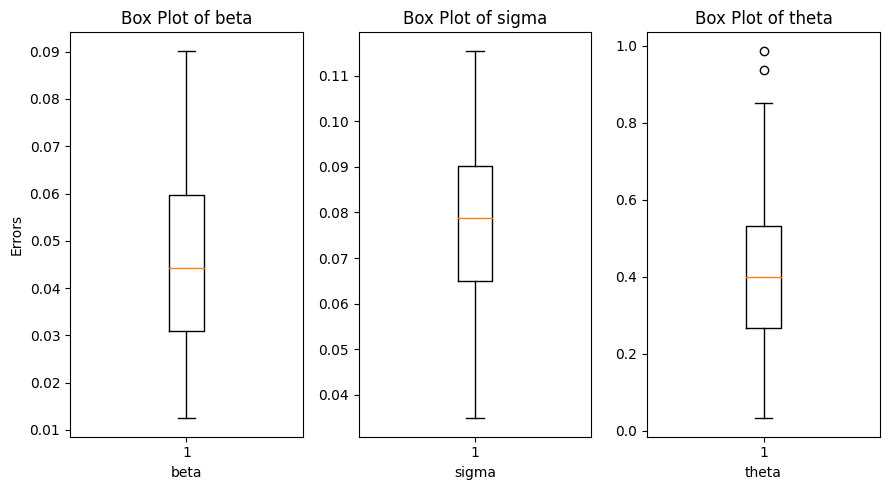

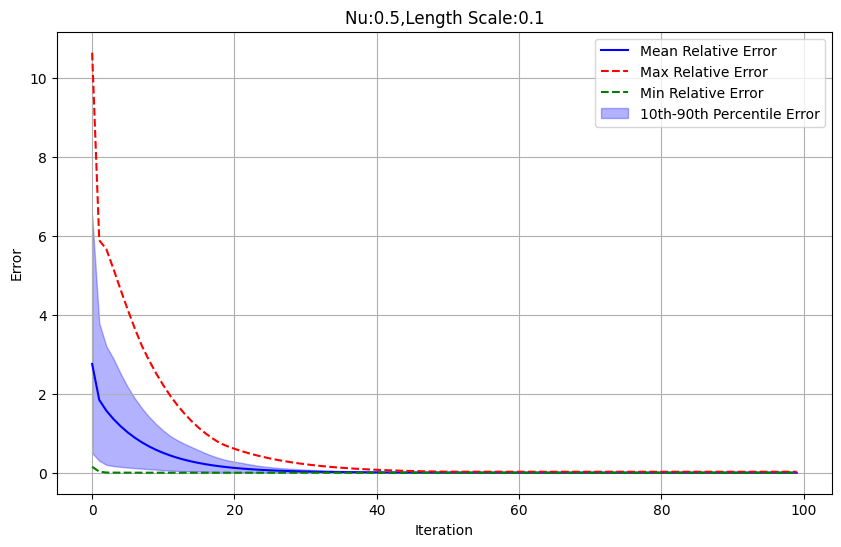

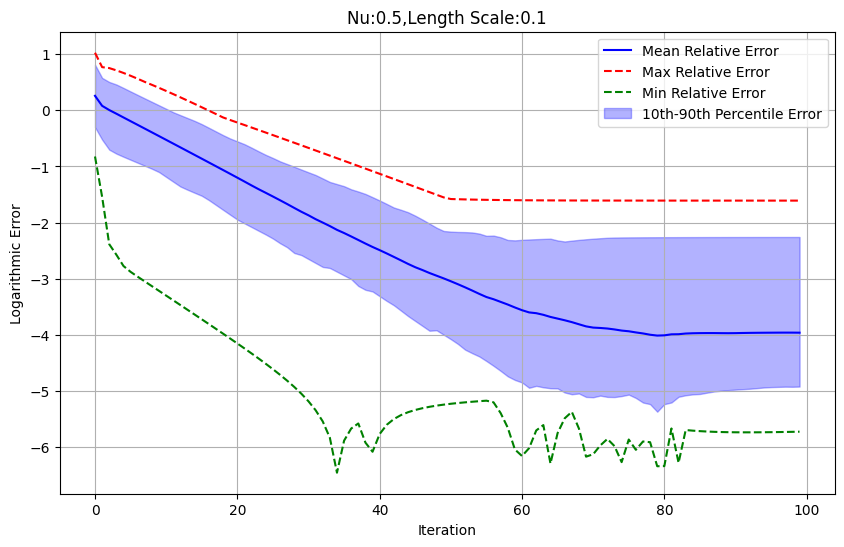

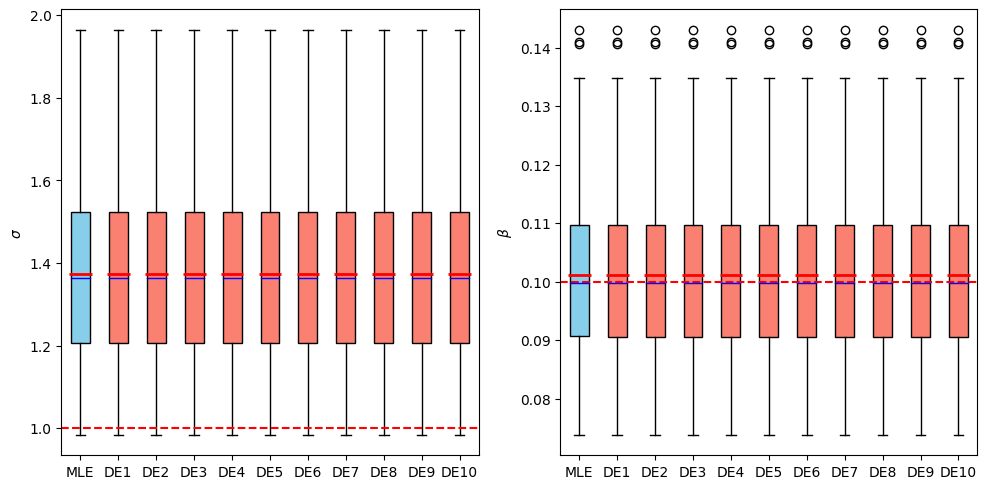

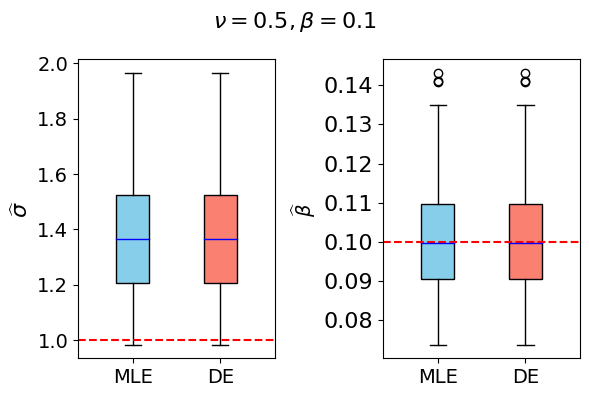

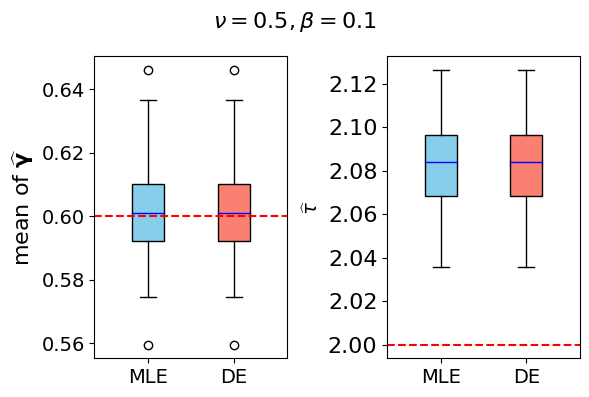

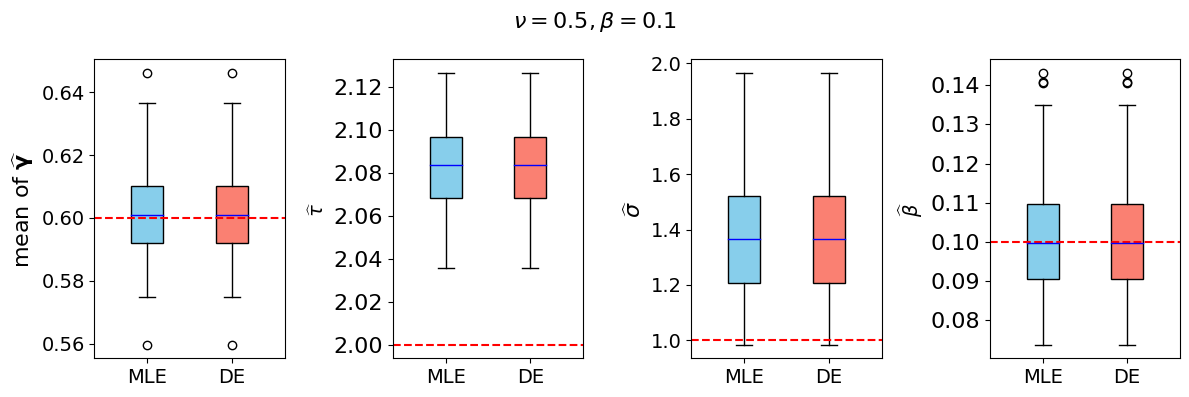

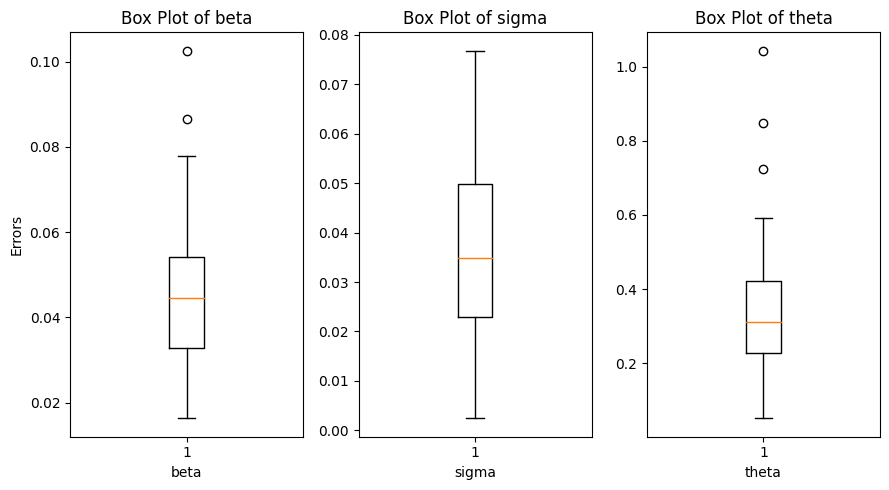

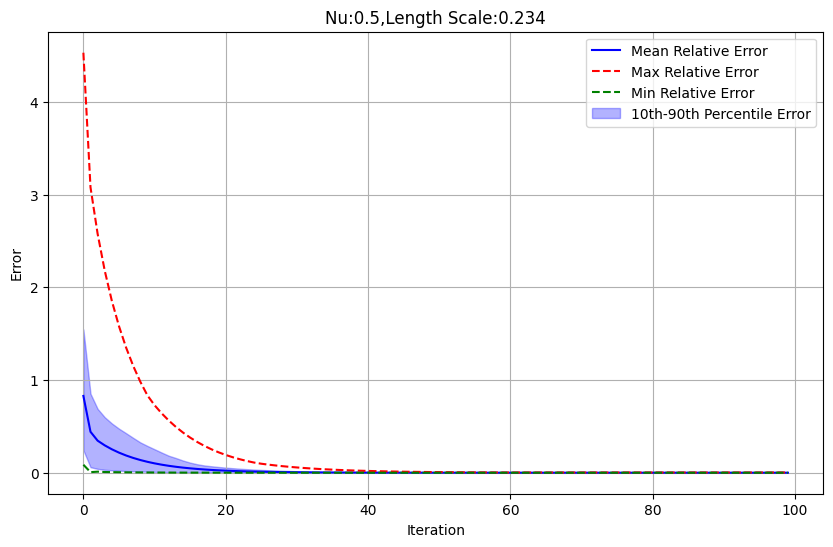

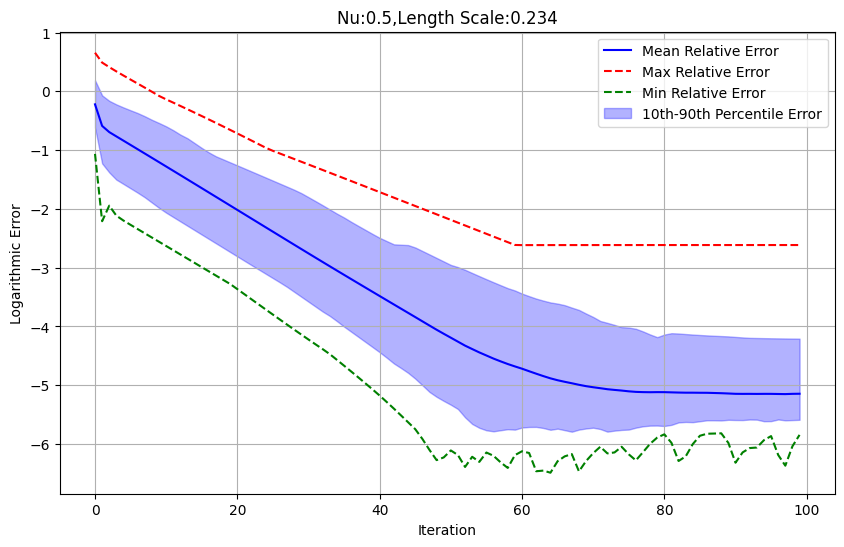

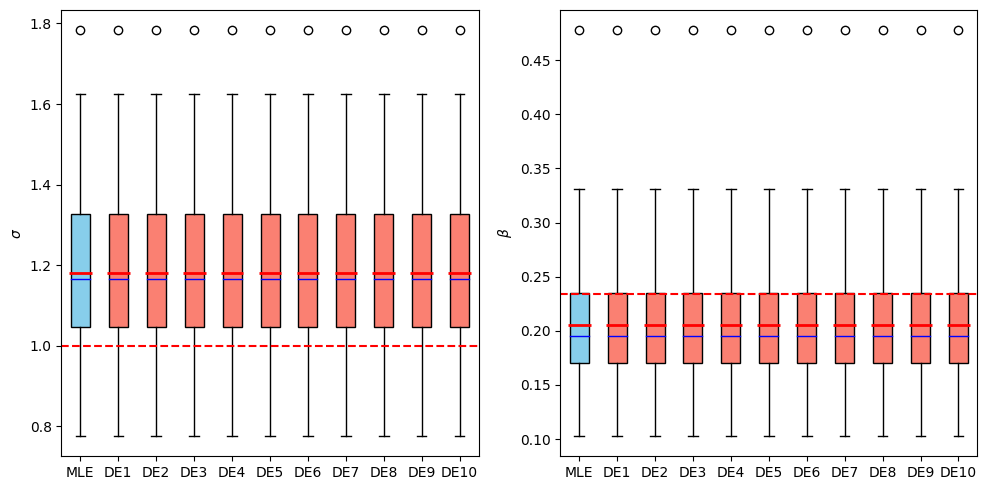

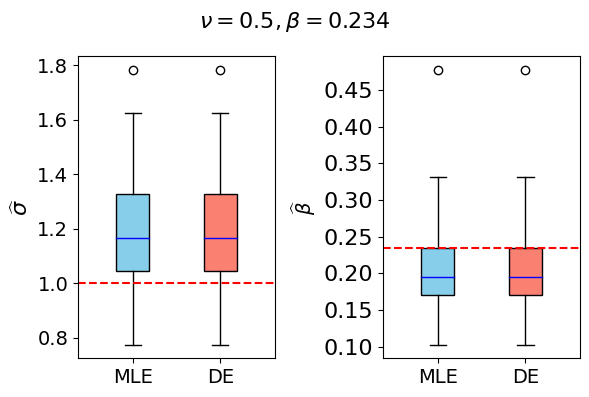

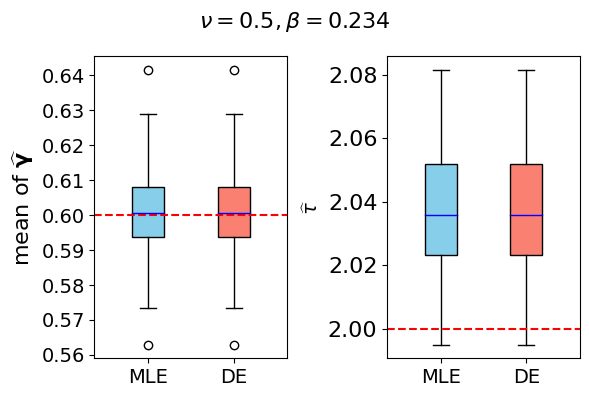

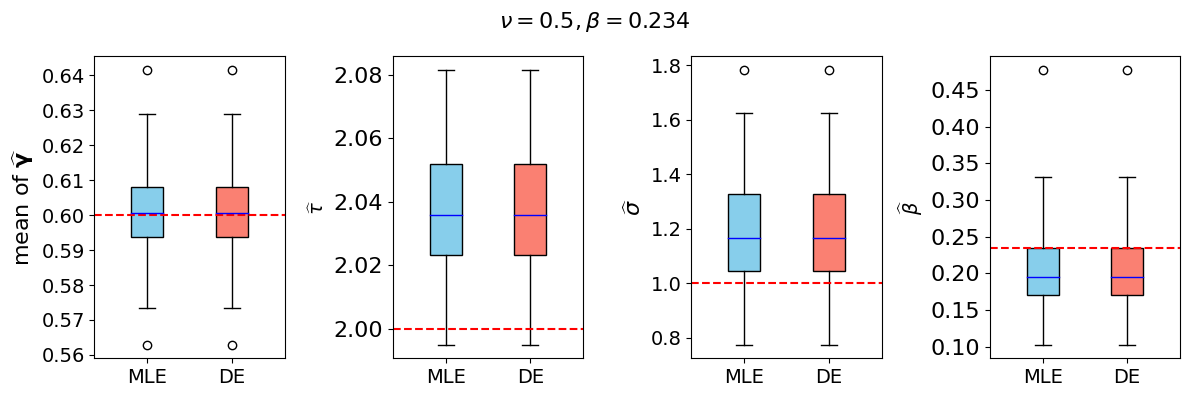

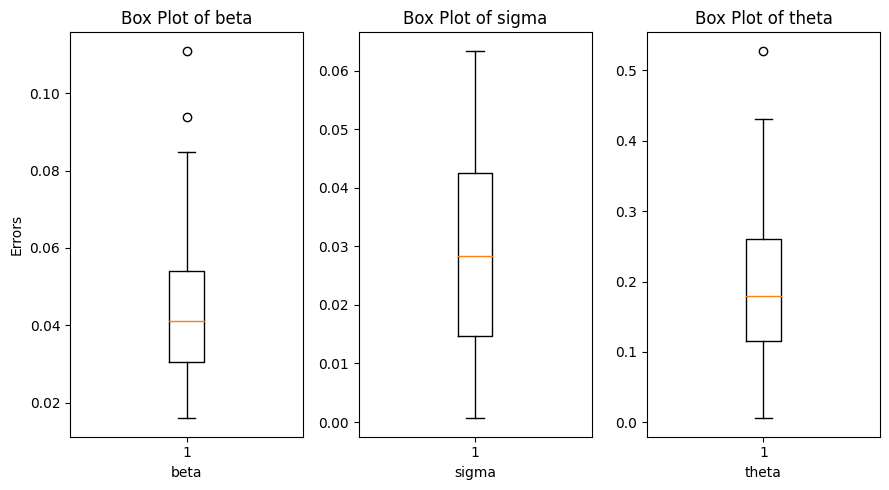

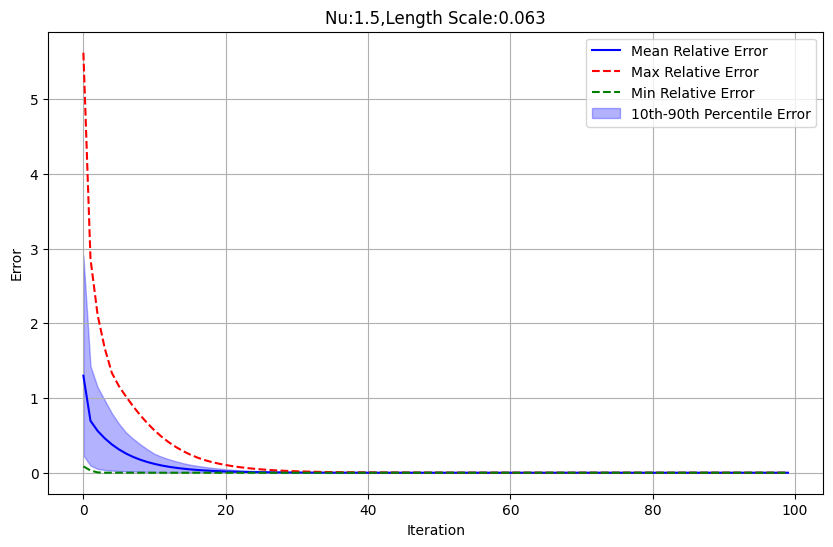

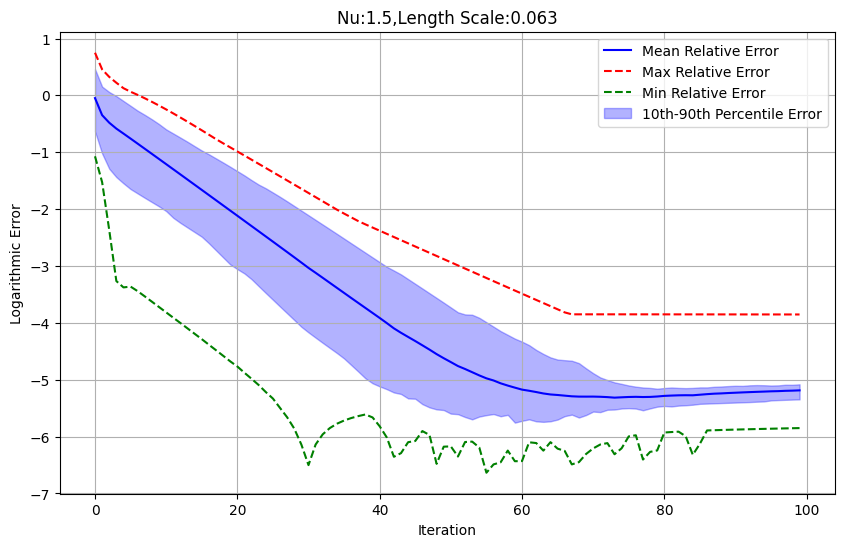

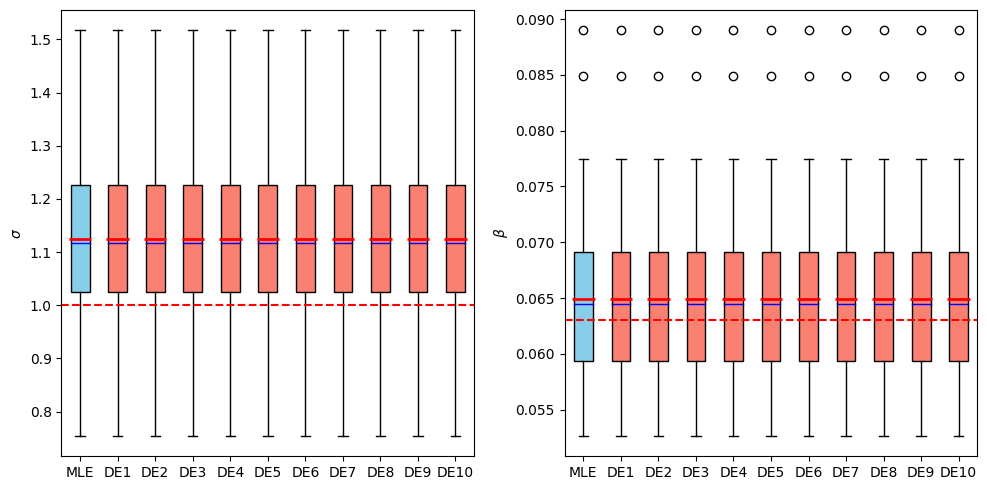

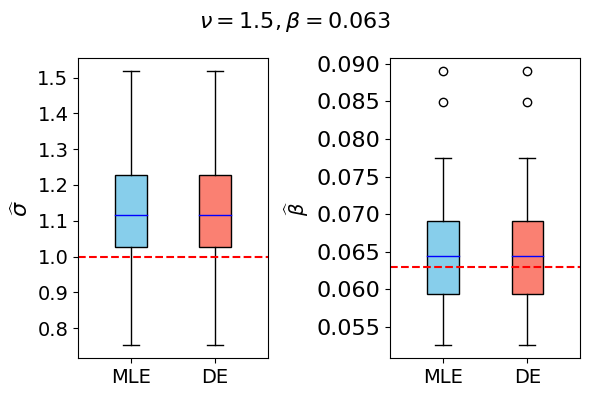

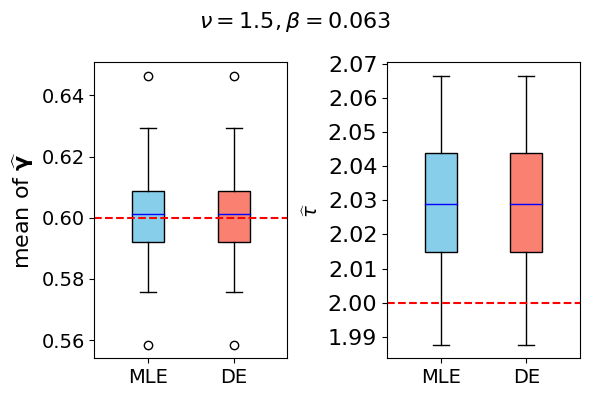

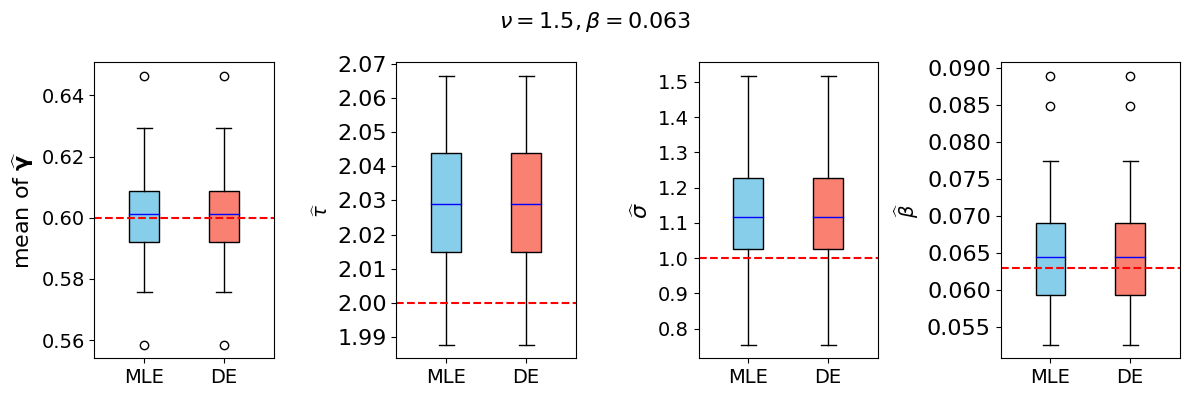

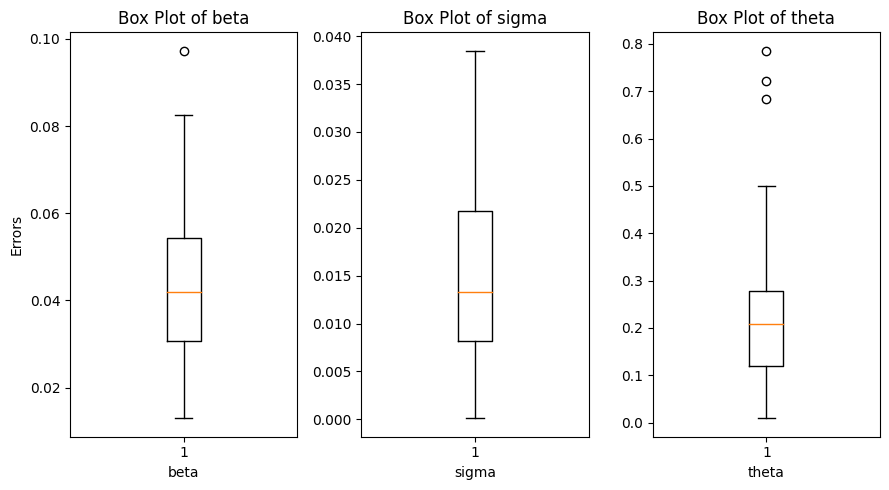

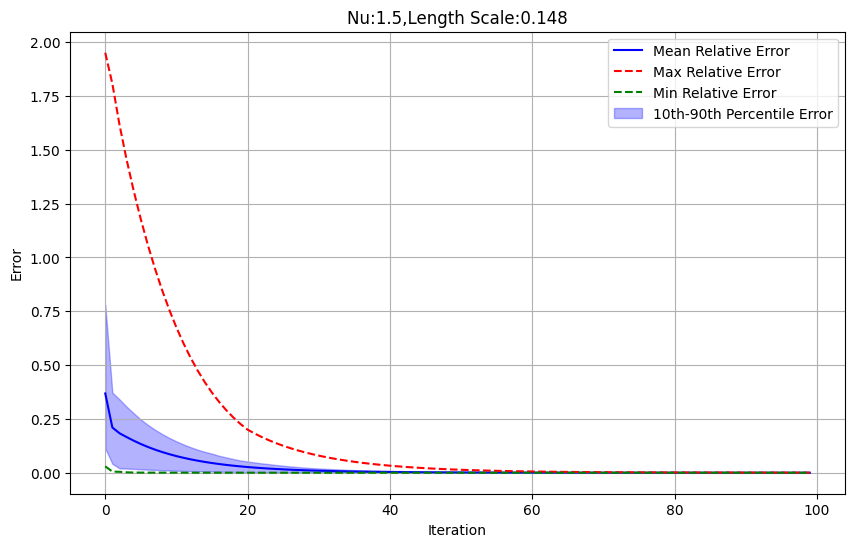

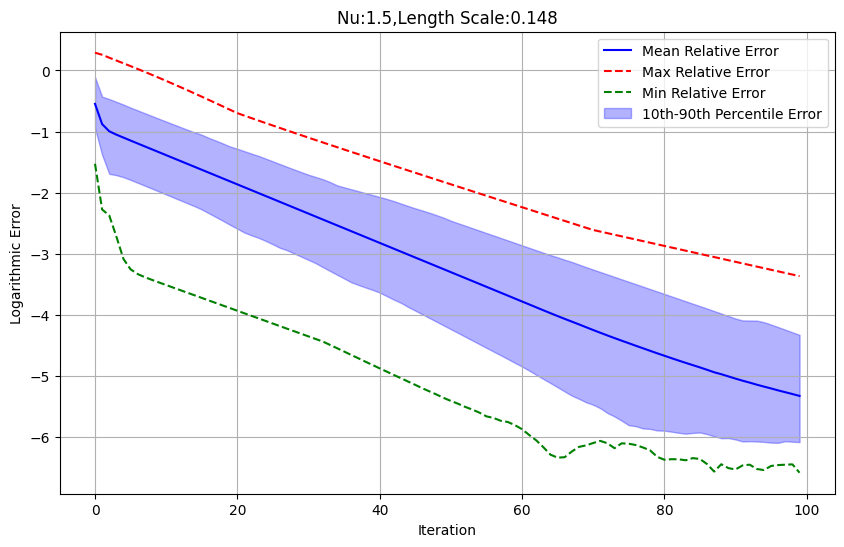

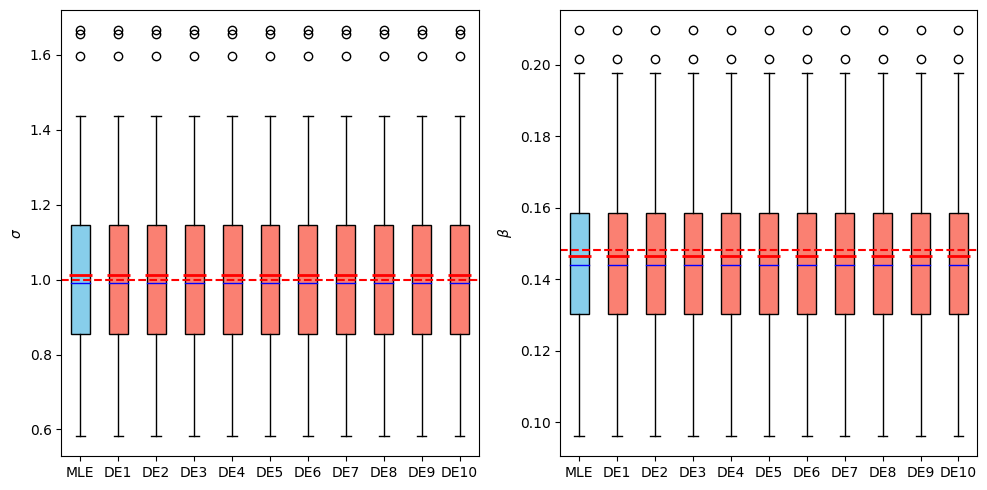

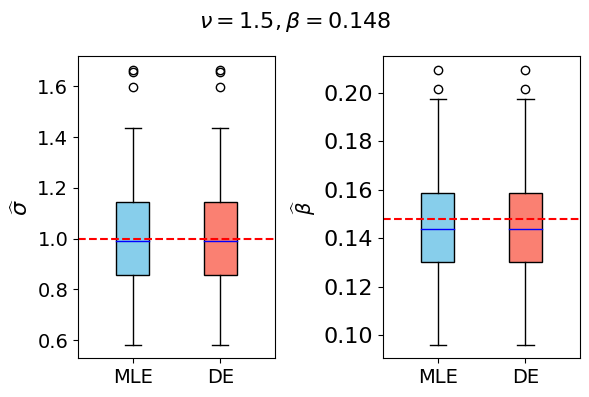

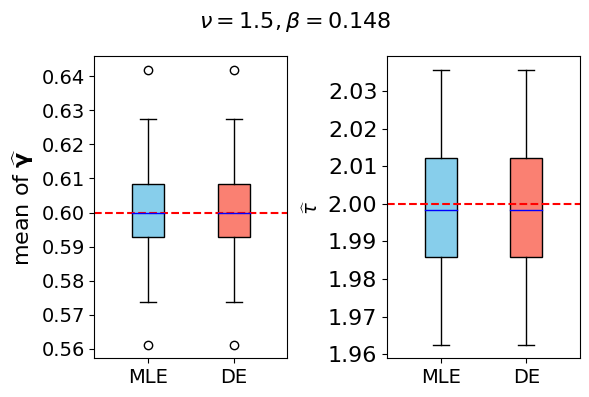

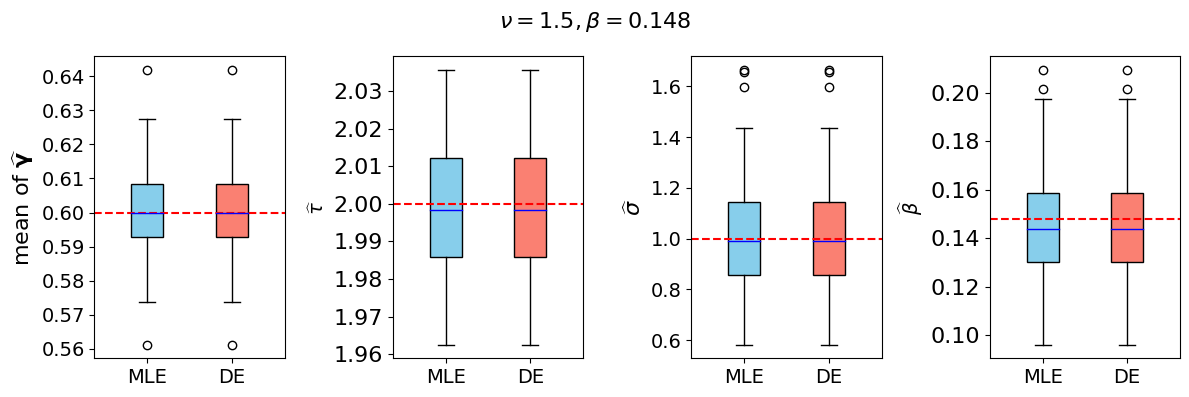

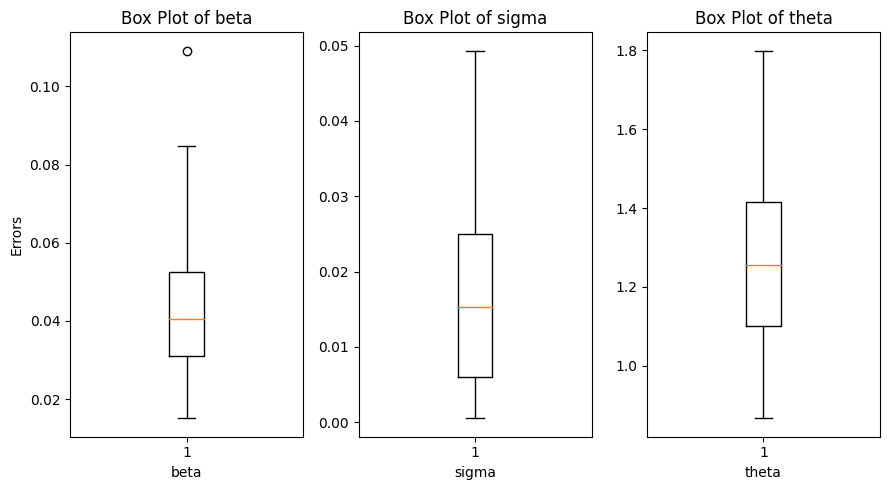

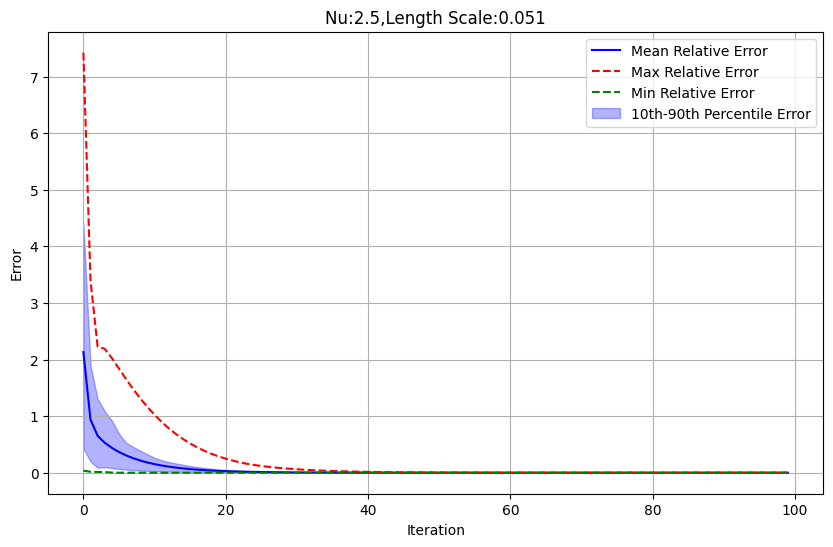

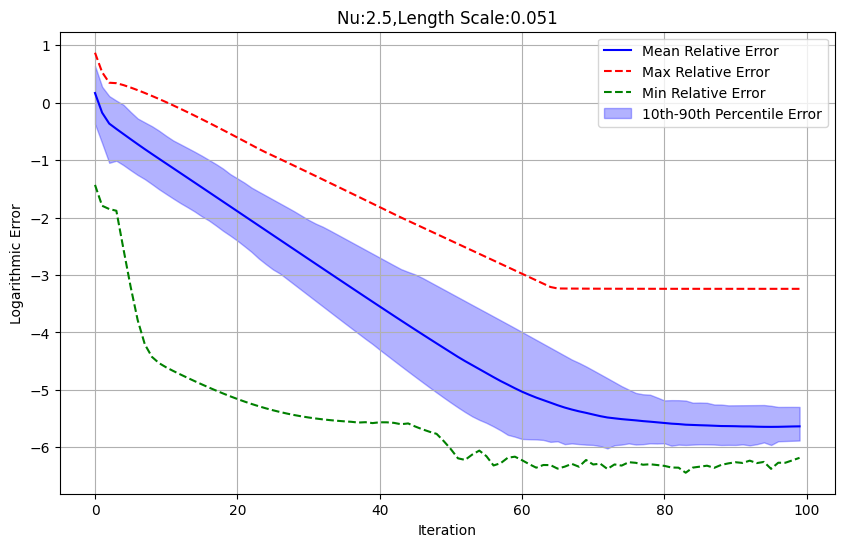

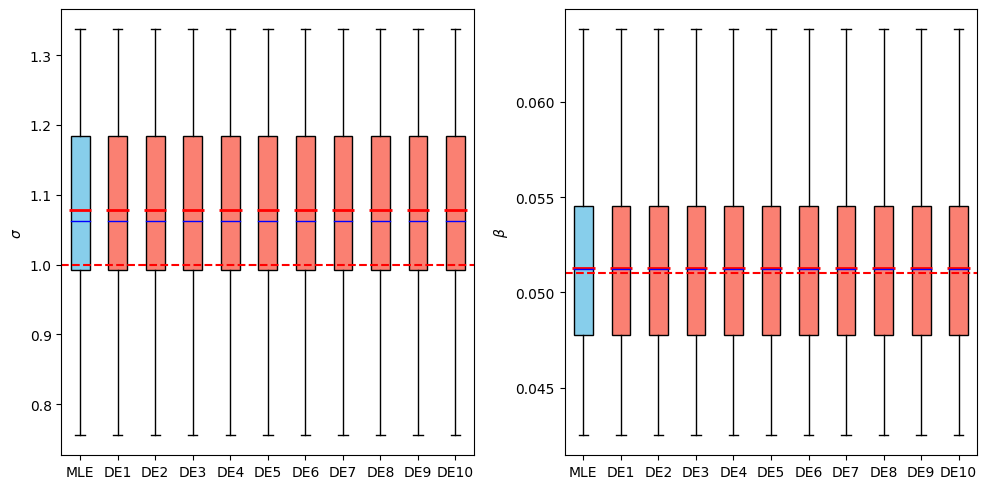

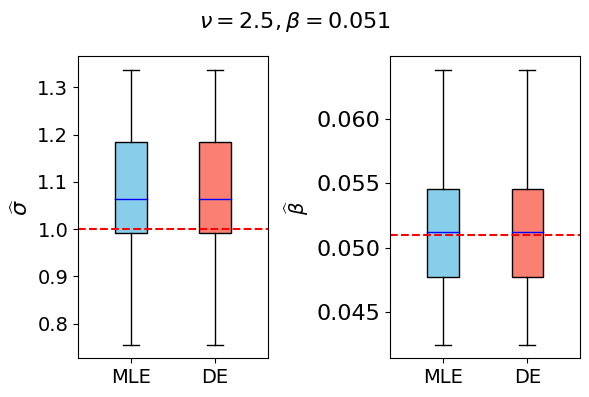

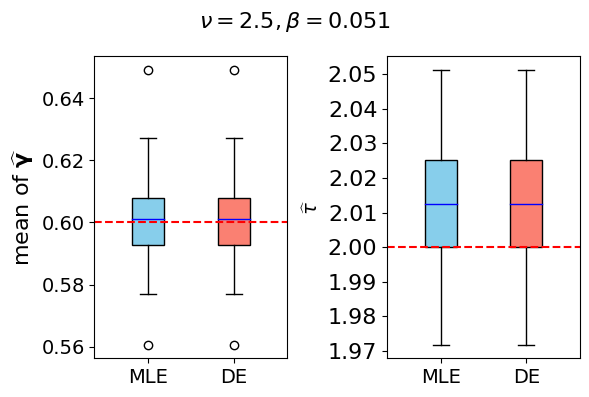

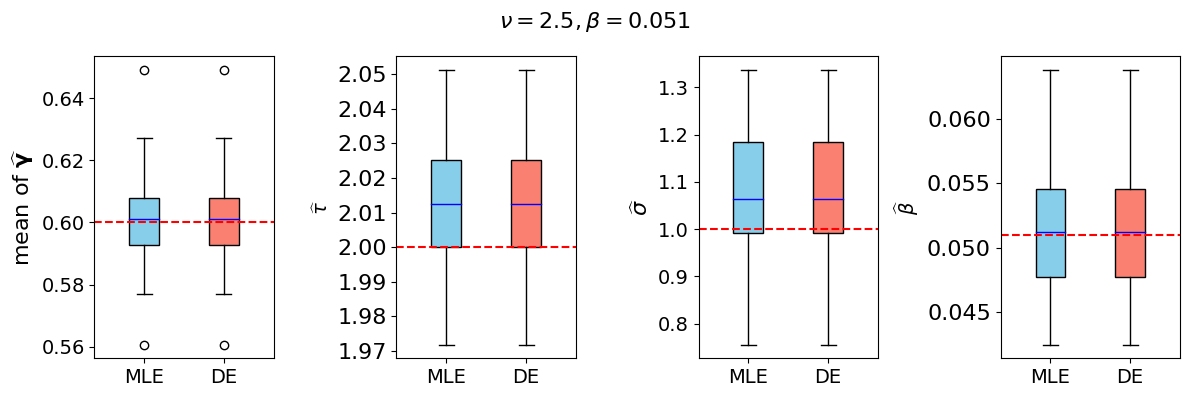

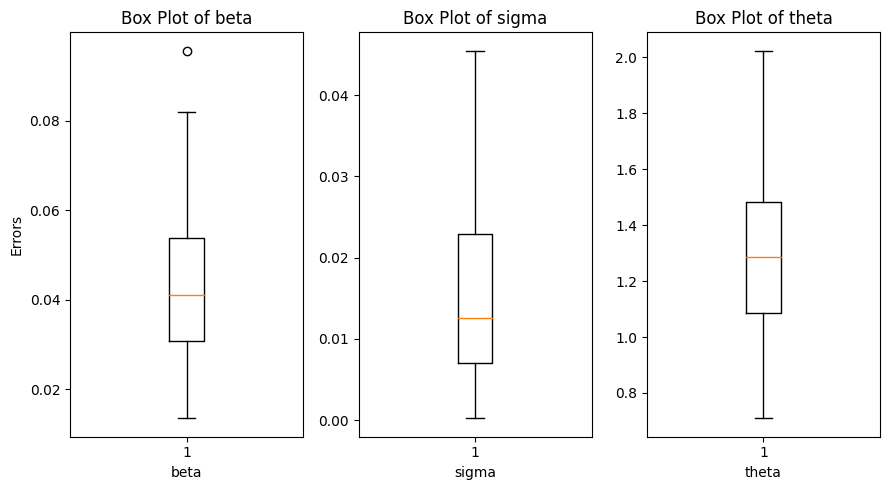

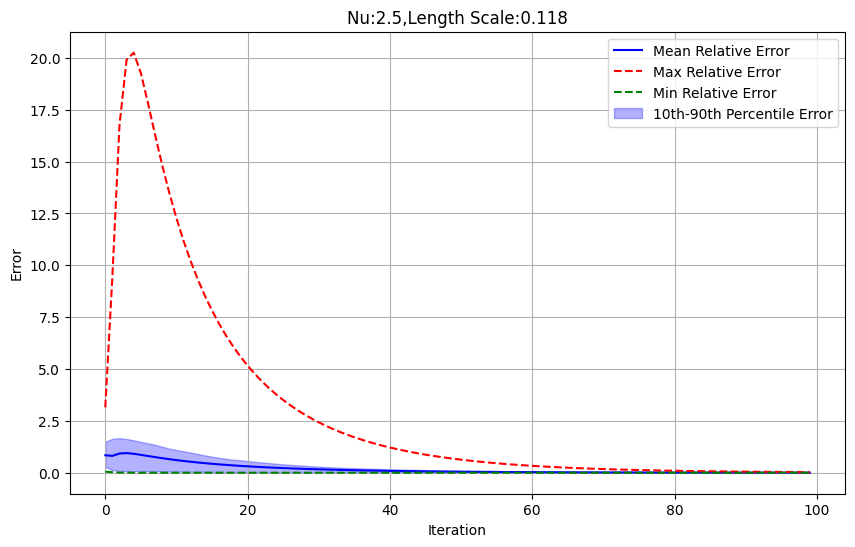

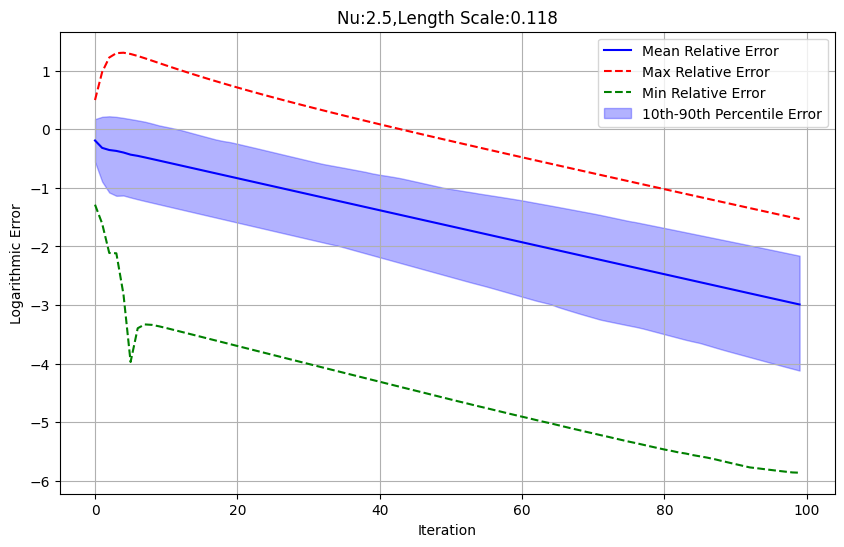

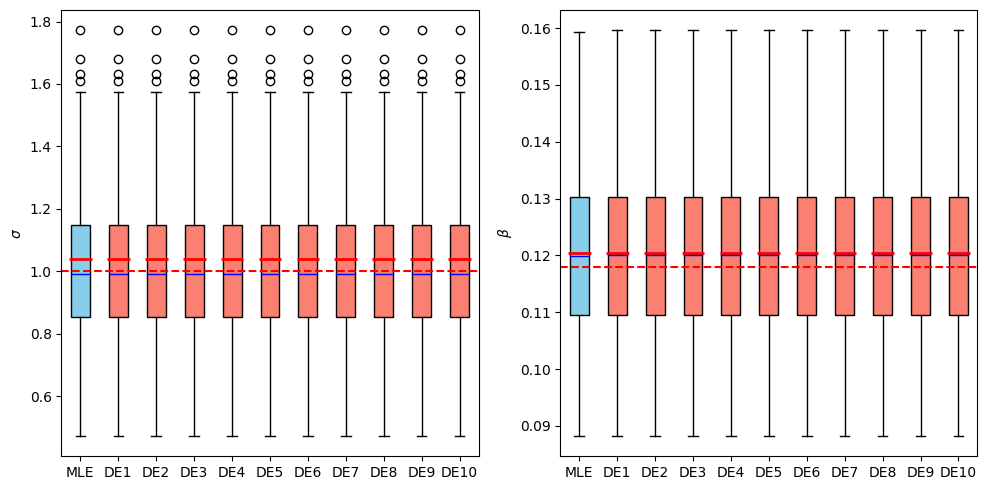

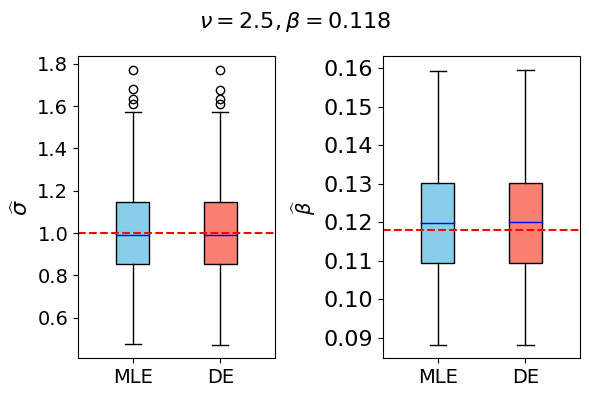

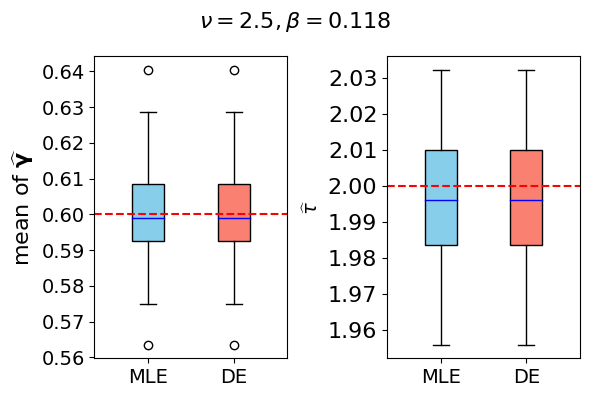

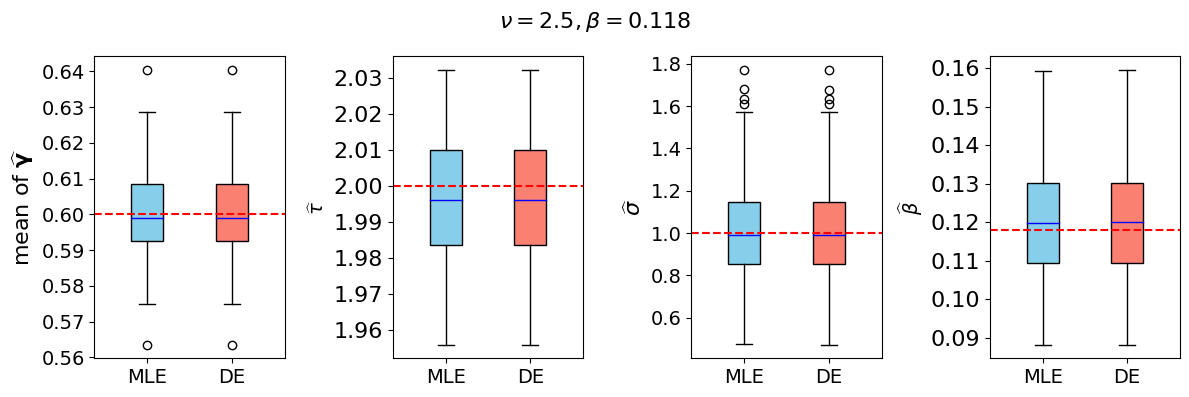

In [3]:

nu_lengths=[(0.5,0.1),(0.5,0.234),(1.5,0.063),(1.5,0.148),(2.5,0.051),(2.5,0.118)]


beta=torch.tensor([-1,2,3,-2,1],dtype=torch.float64)
delta=torch.tensor(0.25,dtype=torch.float64)
alpha=1
J=10

for nu_length in nu_lengths:
    nu=nu_length[0]
    length_scale=nu_length[1]
    theta=torch.tensor([alpha,length_scale],dtype=torch.float64)
    scale=math.sqrt(2*nu)
    if nu==1.5:
        scale=torch.tensor([1,math.sqrt(2*nu)])
    else:
        scale=torch.tensor([1.0,1.0])
    with open(f'expriements/decentralized/misspecified/nu_{nu}_length_scale_{length_scale}_rank_{300}_grid_memeff.pkl', 'rb') as f:
        results=pickle.load(f)
    param_rel_error=np.zeros(shape=(100,100))
    sta_error_beta=np.zeros(shape=(100,))
    sta_error_delta=np.zeros(shape=(100,))
    sta_error_theta=np.zeros(shape=(100,))
    for r in range(100):
        
        sta_error_beta[r]=torch.norm((results[r][1][2].squeeze()-beta)/torch.abs(beta))
        sta_error_delta[r]=torch.norm((results[r][1][3].squeeze()-delta)/torch.abs(delta))
        sta_error_theta[r]=torch.norm((results[r][1][4].squeeze()/scale-theta)/torch.abs(theta))
        for t in range(100):
            rel_error=torch.zeros((J,))
            for j in range(J):
                rel_dif_beta=torch.abs(results[r][0][2][t][j]-results[r][1][2]).squeeze()/torch.abs(beta)
                rel_dif_delta=torch.abs(results[r][0][3][t][j]-results[r][1][3]).squeeze()/torch.abs(delta)
                rel_dif_theta=torch.abs(results[r][0][4][t][j]/scale-results[r][1][4]/scale).squeeze()/torch.abs(theta)
                rel_error[j]=torch.sqrt(torch.square(torch.norm(rel_dif_beta))+torch.square(torch.norm(rel_dif_delta))+torch.square(torch.norm(rel_dif_theta)))
            param_rel_error[r,t]=rel_error.max().numpy()
    
    # Calculate the mean, standard deviation, max, and min across replications for each iteration
    
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    

    #box plot
    fig, axs = plt.subplots(1, 3, figsize=(9, 5))
    axs[0].boxplot(sta_error_beta)
    axs[0].set_title('Box Plot of beta')
    axs[0].set_xlabel('beta')
    axs[0].set_ylabel('Errors')

    # Plot the second box plot for sta_error_delta
    axs[1].boxplot(sta_error_delta)
    axs[1].set_title('Box Plot of sigma')
    axs[1].set_xlabel('sigma')

    # Plot the third box plot for sta_error_theta
    axs[2].boxplot(sta_error_theta)
    axs[2].set_title('Box Plot of theta')
    axs[2].set_xlabel('theta')

    #Adjust layout and display the plots
    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/misspecified/stat_error_nu_{nu}_length_scale_{length_scale}_rank_{300}.pdf', dpi=300)
    plt.show()

    # Plot the mean convergence curve
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'Nu:{nu},Length Scale:{length_scale}')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/misspecified/opt_error_nu_{nu}_length_scale_{length_scale}_rank_{300}.pdf', dpi=300)  
    # Show the plot
    plt.show()


    param_rel_error=np.log10(param_rel_error)
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'Nu:{nu},Length Scale:{length_scale}')
    plt.xlabel('Iteration')
    plt.ylabel('Logarithmic Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/misspecified/opt_logerror_nu_{nu}_length_scale_{length_scale}_rank_{300}.pdf', dpi=300)  
    # Show the plot
    plt.show()

    plt.figure(figsize=(10, 5))

    #box plot for covariance parameter theta
    alphas_de=np.zeros((100,10))
    length_scales_de=np.zeros((100,10))
    betas_de=np.zeros((100,10,5))
    deltas_de=np.zeros((100,10))
    
    
    alphas_mle=np.zeros((100,))
    length_scales_mle=np.zeros((100,))
    betas_mle=np.zeros((100,5))
    deltas_mle=np.zeros((100,))
    
    scale=math.sqrt(2*nu)
    for r in range(100):
        alphas_mle[r]=results[r][1][4][0]
        length_scales_mle[r]=results[r][1][4][1]/scale
        betas_mle[r,:]=results[r][1][2].squeeze()
        deltas_mle[r]=results[r][1][3]
        
        for j in range(10): 
            alphas_de[r,j]=results[r][0][4][99][j][0]
            length_scales_de[r,j]=results[r][0][4][99][j][1]/scale
            betas_de[r,j,:]=results[r][0][2][99][j].squeeze()
            deltas_de[r,j]=results[r][0][3][99][j]
            
    # Box plot for alphas
    plt.subplot(1, 2, 1)
    colors = ['skyblue']+['salmon' for j in range(10)]
    box=plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE{j+1}' for j in range(10)],patch_artist=True, medianprops={'color': 'blue'})
    
    means = [np.mean(alphas_mle)] + [np.mean(alphas_de[:, j]) for j in range(10)]

    # Add mean lines
    for i, mean in enumerate(means):
        plt.hlines(mean, i + 1 - 0.3, i + 1 + 0.3, color='red', linewidth=2, label='Mean' if i == 0 else "") 
        
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=alpha, color='r', linestyle='--', label=r'True $\sigma$')
    #plt.title('Boxplot for alphas')
    plt.ylabel(r'$\sigma$')
    
    #plt.ylim([0, 2])
   
    # Box plot for length scales
    plt.subplot(1, 2, 2)
    colors = ['skyblue']+['salmon' for j in range(10)]
    box=plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE{j+1}' for j in range(10)],patch_artist=True, medianprops={'color': 'blue'})
        
    means = [np.mean(length_scales_mle)] + [np.mean(length_scales_de[:, j]) for j in range(10)]

    # Add mean lines
    for i, mean in enumerate(means):
        plt.hlines(mean, i + 1 - 0.3, i + 1 + 0.3, color='red', linewidth=2, label='Mean' if i == 0 else "") 
    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=length_scale, color='r', linestyle='--', label=r'True $\beta$')
    #plt.title('Boxplot for Length scales')
    plt.ylabel(r'$\beta$')
    #plt.ylim([0, 0.3])
    

    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/misspecified/boxplot_covpara_nu_{nu}_length_scale_{length_scale}_rank_{300}.pdf', dpi=300)
    plt.show()
    
    
    
    
    
    plt.figure(figsize=(6, 4))
    positions = [0,0.8]
    plt.suptitle(fr'$\nu={nu},\beta={length_scale}$',fontsize=16)
    plt.subplot(1, 2, 1)
    
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([alphas_mle] + [np.mean(alphas_de,axis=1)], labels=['MLE'] + [f'DE'],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=14)    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=alpha, color='r', linestyle='--', label=r'True $\sigma$')
    #plt.title('Boxplot for alphas')
    plt.ylabel(r'$\widehat{\sigma}$',fontsize=16)
    
    #plt.ylim([0, 2])
    
    
    #the similar graph
    # Box plot for length scales
    plt.subplot(1, 2, 2)
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([length_scales_mle] + [np.mean(length_scales_de,axis=1)], labels=['MLE'] + [f'DE' ],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
        
  
    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=length_scale, color='r', linestyle='--', label=r'True $\beta$')
    #plt.title('Boxplot for Length scales')
    plt.ylabel(r'$\widehat{\beta}$',fontsize=14)
    #plt.ylim([0, 0.3])
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=16)    
    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/misspecified/boxplot_covpara_nu_{nu}_length_scale_{length_scale}_rank_{300}_mean_machine.pdf', dpi=300)
    plt.show()
    
    
    
    #***************************
    
    plt.figure(figsize=(6, 4))
    positions = [0,0.8]
    plt.suptitle(fr'$\nu={nu},\beta={length_scale}$',fontsize=16)
    plt.subplot(1, 2, 1)
    
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([np.mean(betas_mle,axis=1)] + [np.mean(np.mean(betas_de,axis=1),axis=1)], labels=['MLE'] + [f'DE'],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=14)    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=torch.mean(beta), color='r', linestyle='--', label=r'True $\mathbf{\gamma}$')
    #plt.title('Boxplot for alphas')
    plt.ylabel(r'mean of $\widehat{\mathbf{\gamma}}$',fontsize=16)
    
    #plt.ylim([0, 2])
    
    
    #the similar graph
    # Box plot for length scales
    plt.subplot(1, 2, 2)
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([np.sqrt(1/deltas_mle)] + [np.mean(np.sqrt(1/deltas_de),axis=1)], labels=['MLE'] + [f'DE' ],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
        
  
    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=torch.sqrt(1/delta), color='r', linestyle='--', label=r'True $\tau$')
    #plt.title('Boxplot for Length scales')
    plt.ylabel(r'$\widehat{\tau}$',fontsize=14)
    #plt.ylim([0, 0.3])
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=16)    
    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/misspecified/boxplot_beta_delta_nu_{nu}_length_scale_{length_scale}_rank_{300}_mean_machine.pdf', dpi=300)
    plt.show()
    
    
    #***************************************************all parameters************************
    plt.figure(figsize=(12, 4))
    positions = [0,0.8]
    plt.suptitle(fr'$\nu={nu},\beta={length_scale}$',fontsize=16)
    plt.subplot(1, 4, 1)
    
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([np.mean(betas_mle,axis=1)] + [np.mean(np.mean(betas_de,axis=1),axis=1)], labels=['MLE'] + [f'DE'],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=14)    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=torch.mean(beta), color='r', linestyle='--', label=r'True $\mathbf{\gamma}$')
    #plt.title('Boxplot for alphas')
    plt.ylabel(r'mean of $\widehat{\mathbf{\gamma}}$',fontsize=16)
    plt.tight_layout()
    #plt.ylim([0, 2])
    

    plt.subplot(1, 4, 2)
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([np.sqrt(1/deltas_mle)] + [np.mean(np.sqrt(1/deltas_de),axis=1)], labels=['MLE'] + [f'DE' ],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
        
  
    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=torch.sqrt(1/delta), color='r', linestyle='--', label=r'True $\tau$')
    #plt.title('Boxplot for Length scales')
    plt.ylabel(r'$\widehat{\tau}$',fontsize=14)
    #plt.ylim([0, 0.3])
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=16)    
    plt.tight_layout()
    
    
    
    plt.subplot(1, 4, 3)
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([alphas_mle] + [np.mean(alphas_de,axis=1)], labels=['MLE'] + [f'DE'],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=14)    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=alpha, color='r', linestyle='--', label=r'True $\sigma$')
    #plt.title('Boxplot for alphas')
    plt.ylabel(r'$\widehat{\sigma}$',fontsize=16)
    plt.tight_layout()
   
    plt.subplot(1, 4, 4)
    colors = ['skyblue']+['salmon']
    box=plt.boxplot([length_scales_mle] + [np.mean(length_scales_de,axis=1)], labels=['MLE'] + [f'DE' ],patch_artist=True, medianprops={'color': 'blue'},positions=positions, widths=0.3)
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.axhline(y=length_scale, color='r', linestyle='--', label=r'True $\beta$')
    #plt.title('Boxplot for Length scales')
    plt.ylabel(r'$\widehat{\beta}$',fontsize=14)
    #plt.ylim([0, 0.3])
    plt.xticks(positions, ['MLE', 'DE'], rotation=0, fontsize=14)
    plt.yticks(fontsize=16)    
    plt.tight_layout()
    
    
    
    plt.savefig(f'expriements/decentralized/misspecified/boxplot_all_nu_{nu}_length_scale_{length_scale}_rank_{300}_mean_machine.pdf', dpi=300)
    plt.show()
    
